In [1]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
import lib_plot


Eigenvalues = [-8.59332218 -4.6003875   0.98805764  5.96812708]


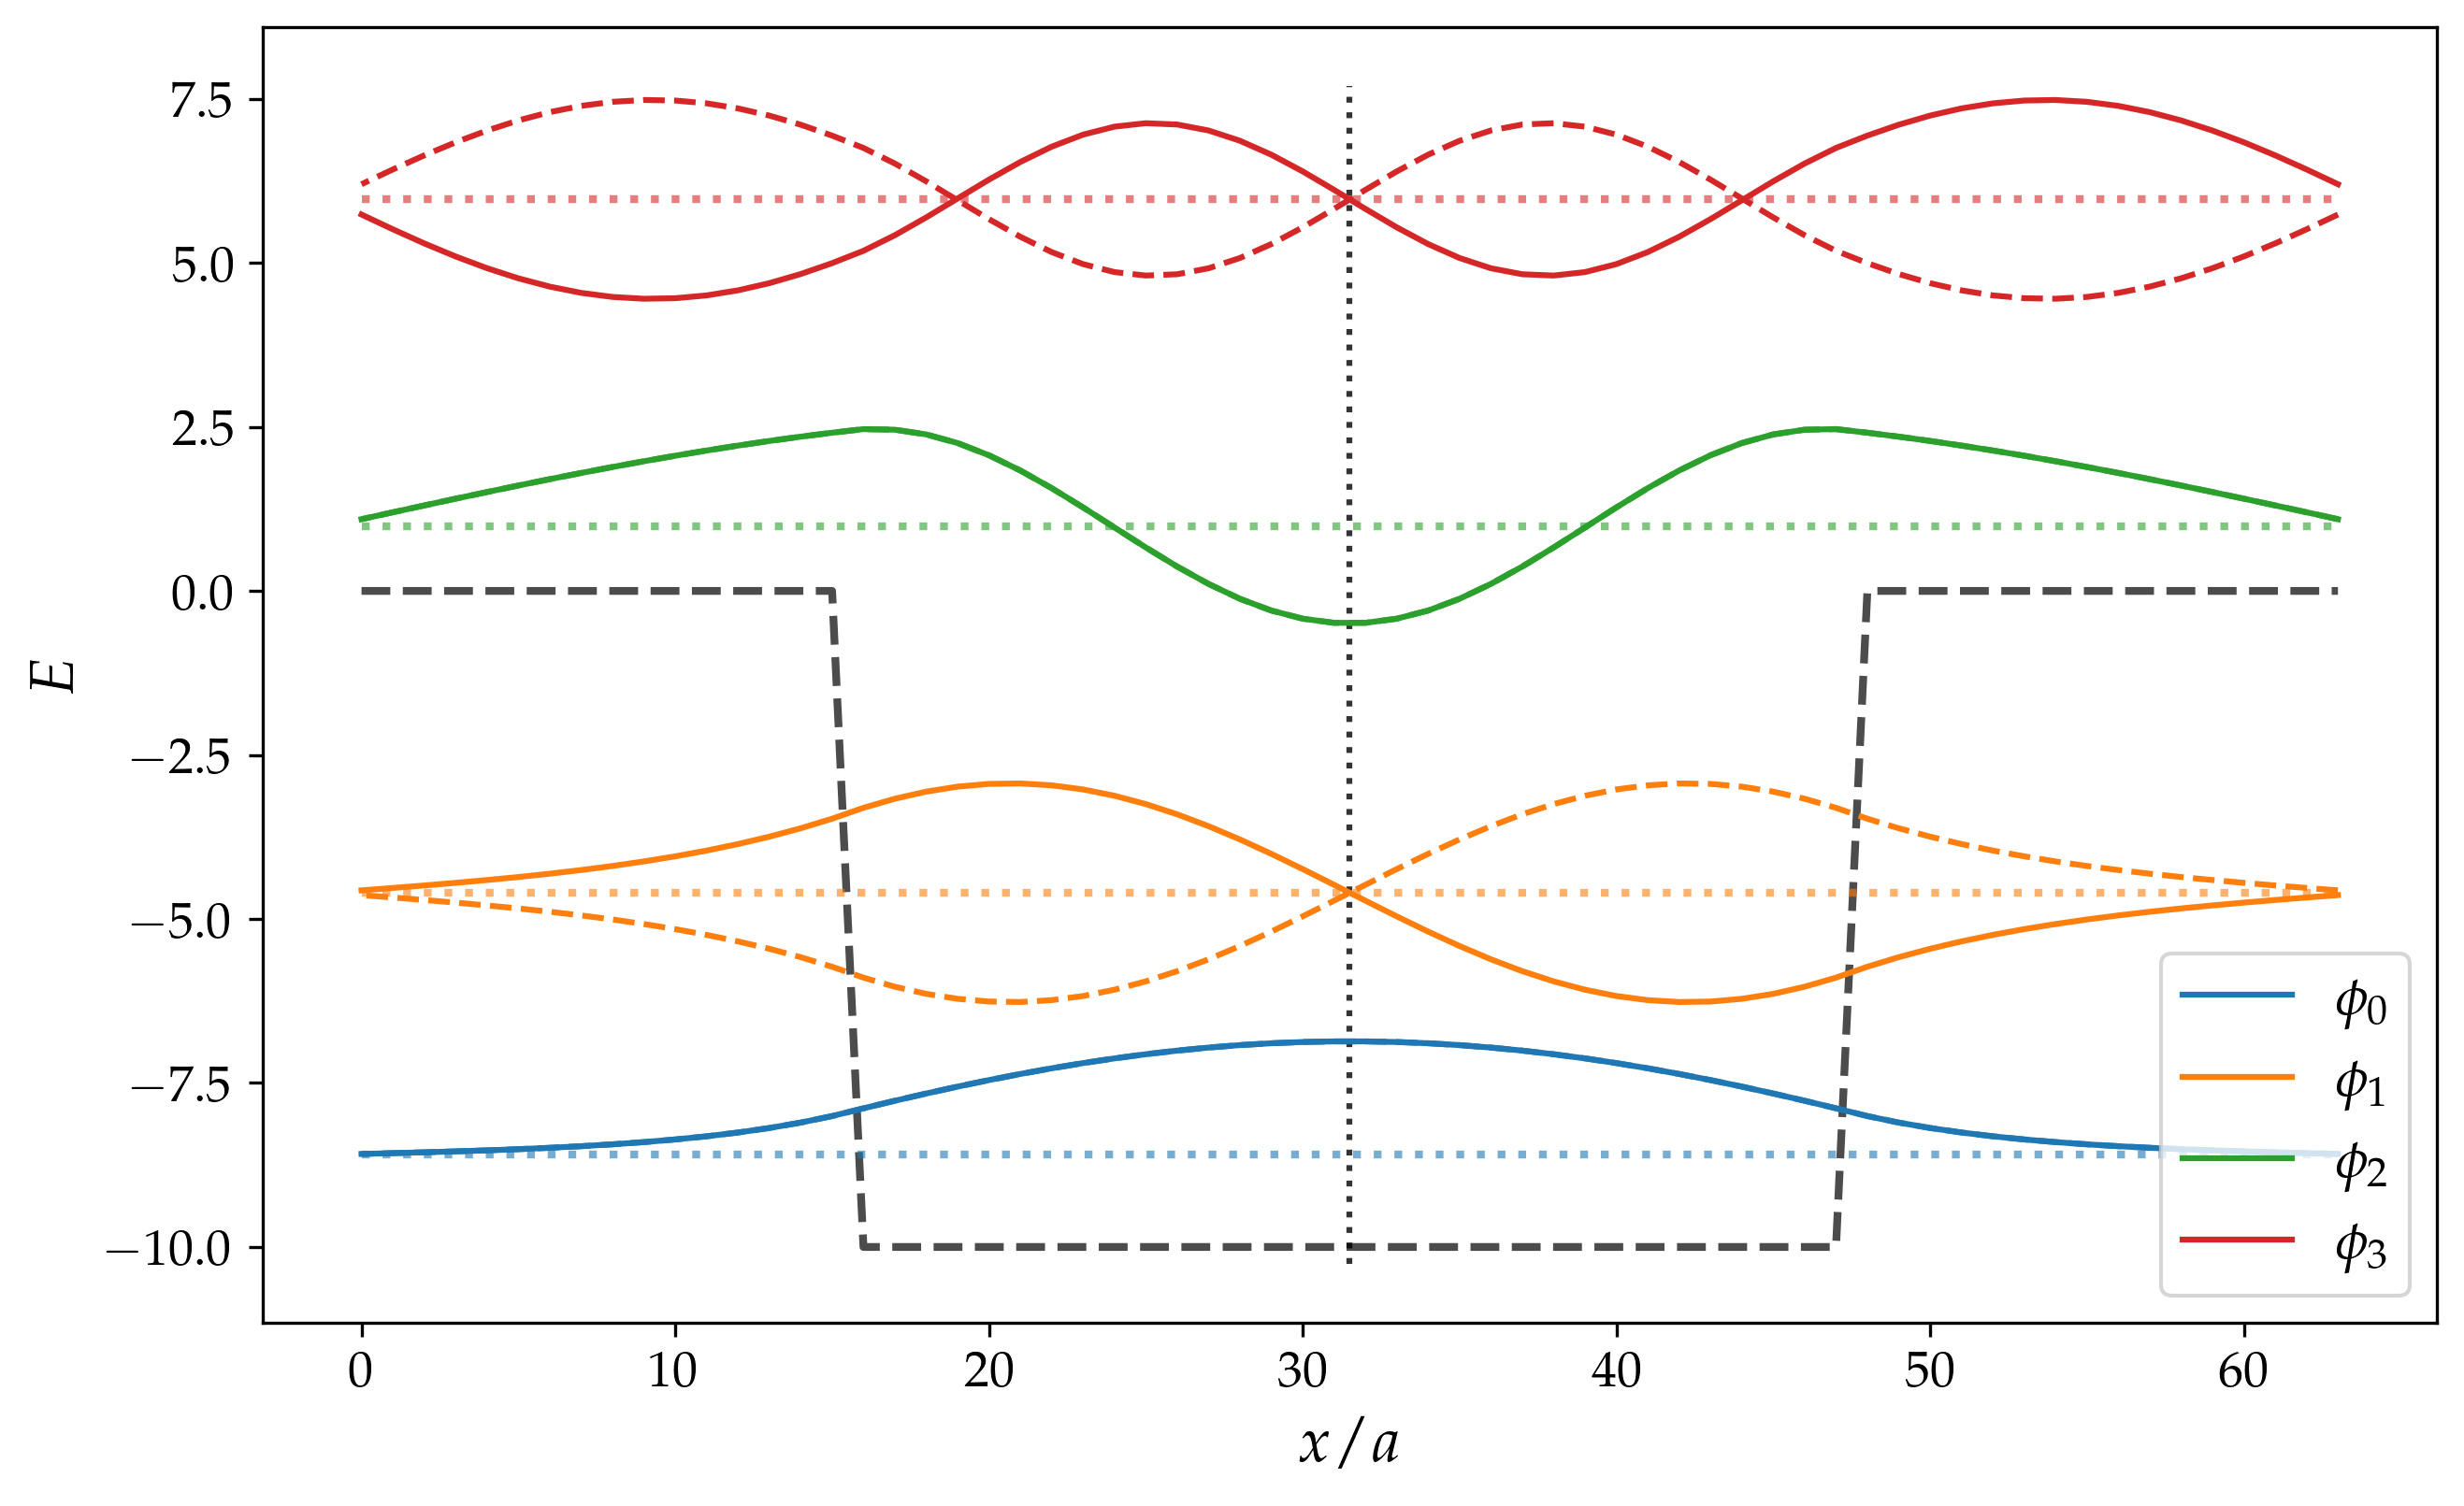

In [2]:
from data_V import N_points, V0_L, mL, StaticV

tot_eig_val = np.loadtxt('V_values.txt')
tot_eig_vect = np.loadtxt('V_vectors.txt')

selec = 4
eig_val = np.copy(tot_eig_val)[:selec]
eig_vect = np.copy(tot_eig_vect)[:, :selec].T

print('Eigenvalues =', eig_val)


xcoo = np.arange(0, N_points)
# cols = color_map(np.linspace(0, 1, selec))
cols = [f'C{i}' for i in range(10)]

plt.figure(figsize=(10, 6))
plt.plot(xcoo, StaticV(xcoo), color='black', ls='--', alpha=0.7, 
         lw=2)
for i, eig in enumerate(eig_val):
    plt.hlines(eig, min(xcoo), max(xcoo), color=cols[i], ls=':', alpha=0.6, lw=2)
    plt.plot(xcoo, mL*eig_vect[i] + eig, color=cols[i], zorder=2,
             label=rf'$\phi_{i}$')
    # symmetry
    plt.plot(np.flip(xcoo), mL*eig_vect[i] + eig, color=cols[i], ls='--', zorder=2)

plt.vlines(xcoo[-1]/2, np.min(eig_vect)*mL+eig_val[0], np.max(eig_vect)*mL+eig_val[-1],
           color='black', ls=':', zorder=0, alpha=0.8)

plt.xlabel(r'$x/a$')
plt.ylabel(r'$E$')
plt.legend(loc='lower right')

plt.savefig('plots/finite_well.png')
plt.show()

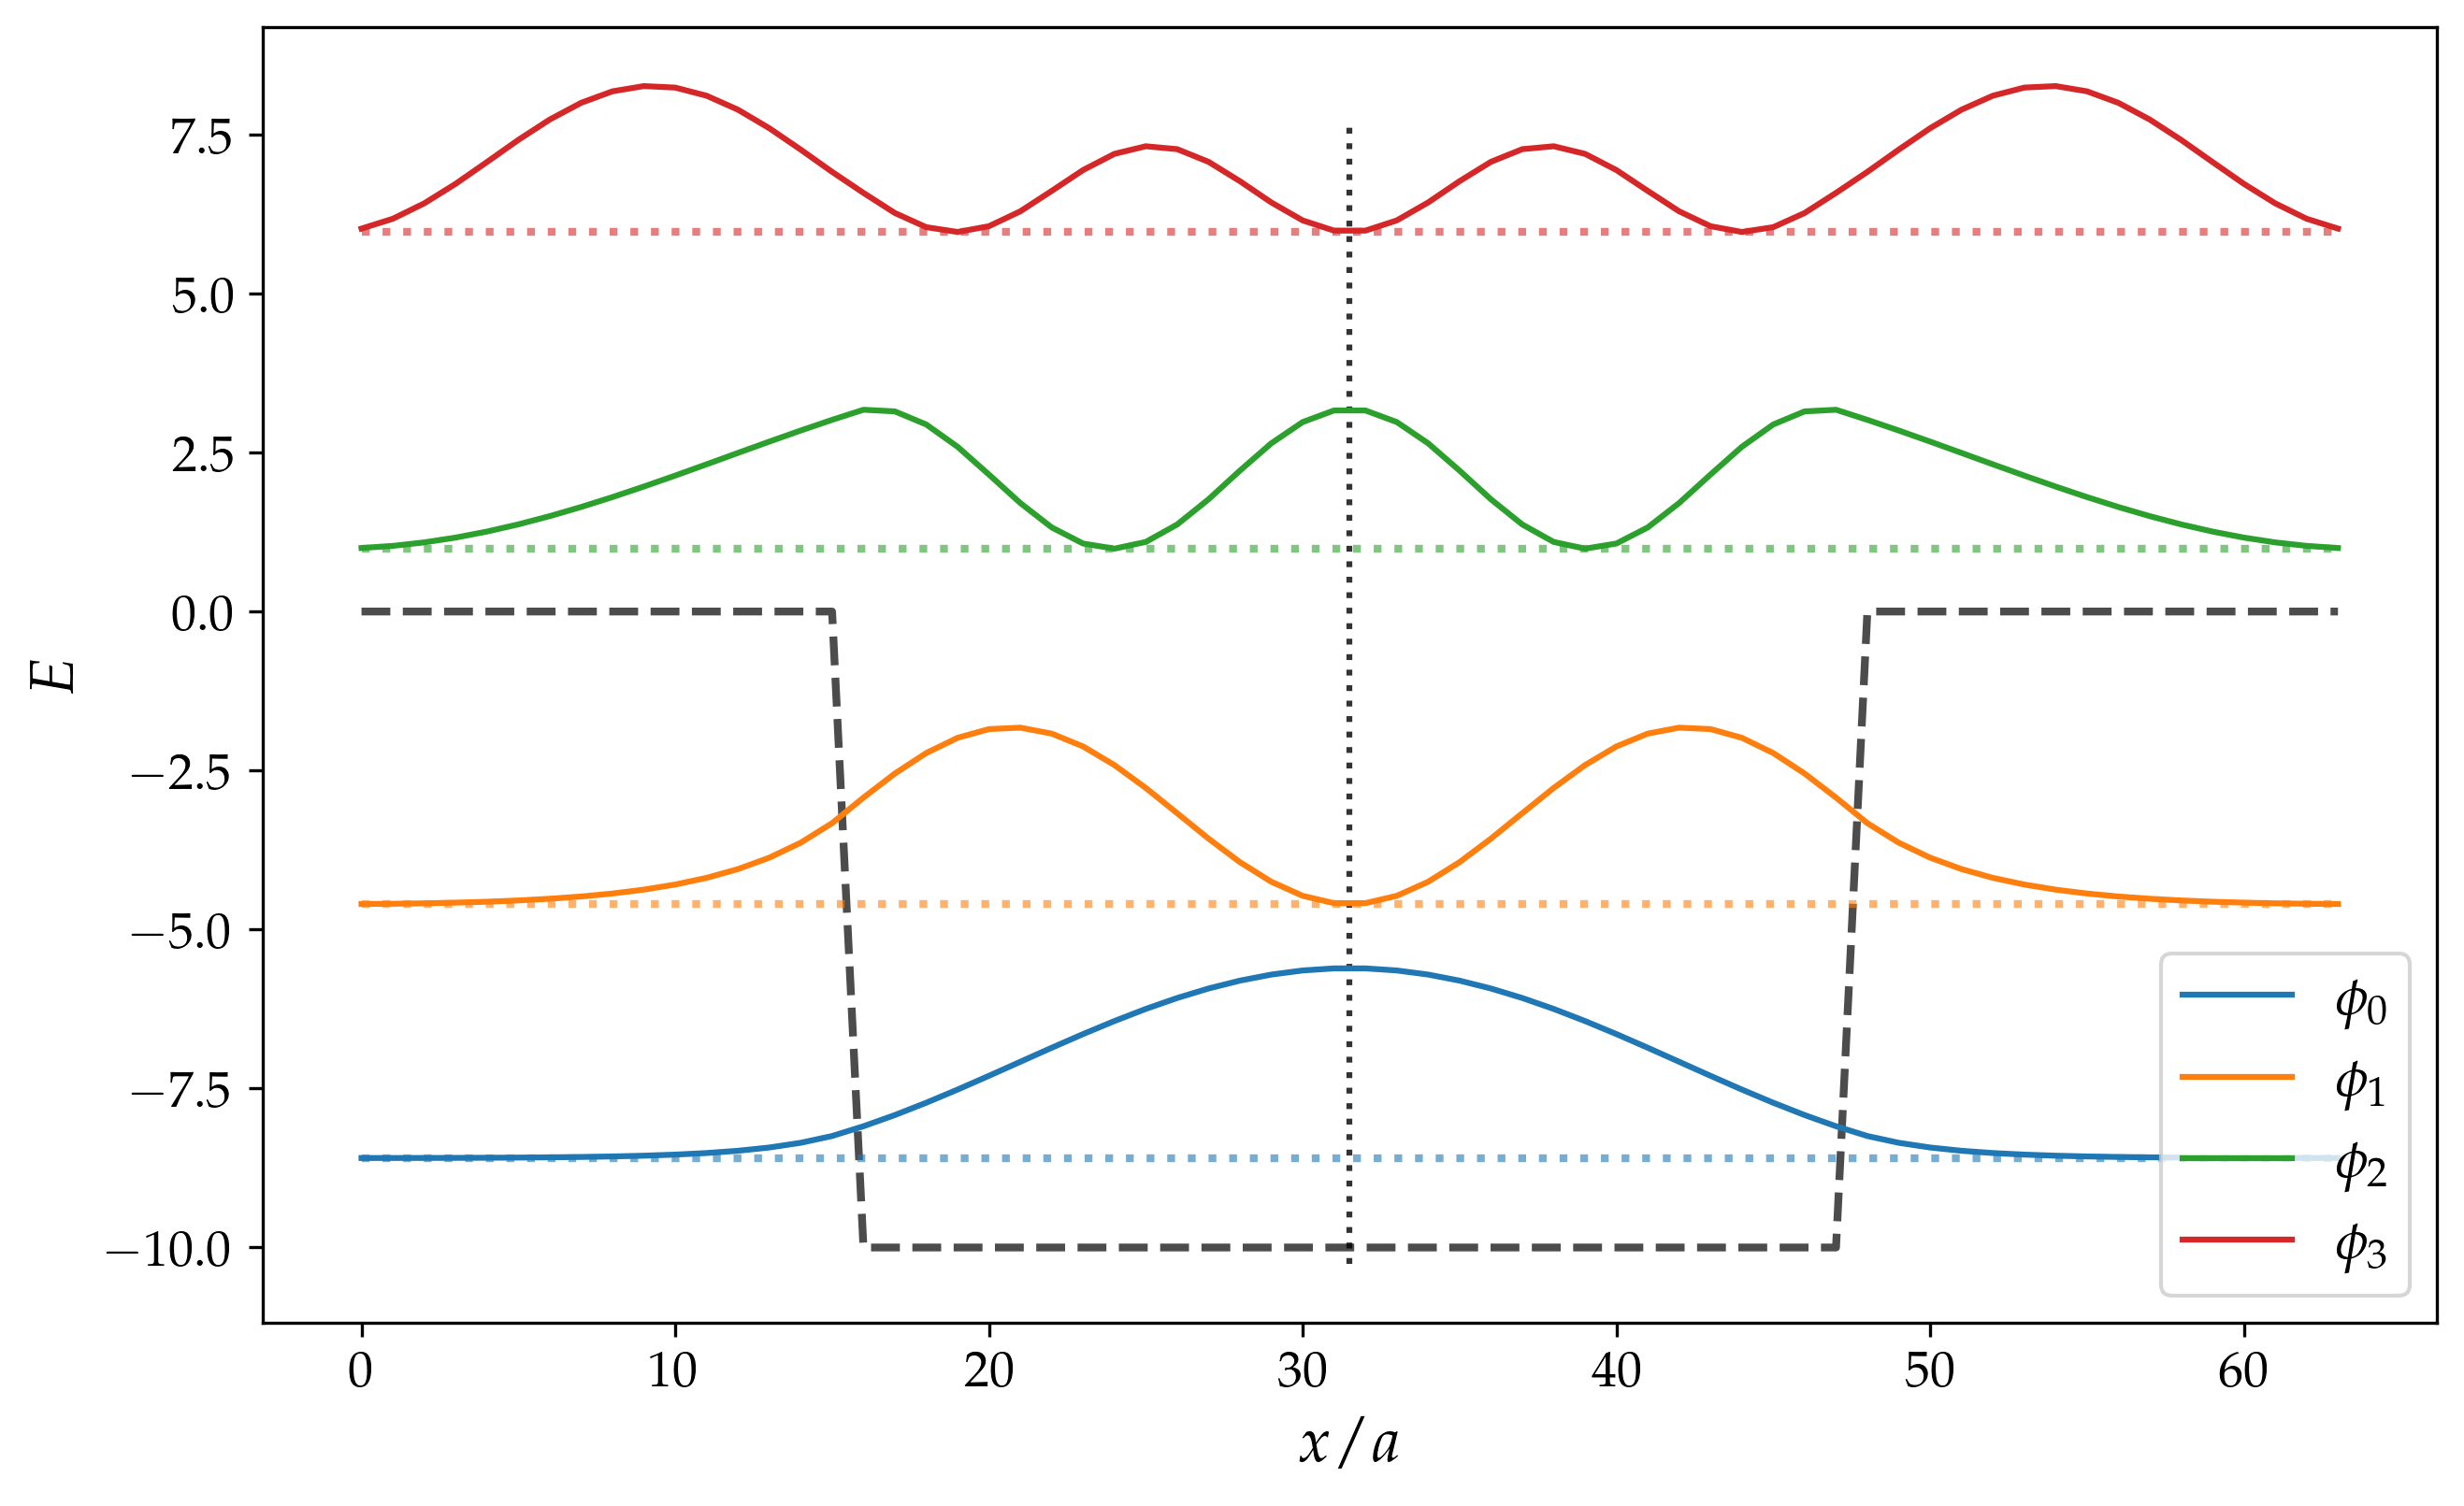

In [3]:
xcoo = np.arange(0, N_points)

plt.figure(figsize=(10, 6))
plt.plot(xcoo, StaticV(xcoo), color='black', ls='--', alpha=0.7, 
         lw=2)
for i, eig in enumerate(eig_val):
    plt.hlines(eig, min(xcoo), max(xcoo), color=cols[i], ls=':', alpha=0.6, lw=2)
    
    plt.plot(xcoo, (mL*eig_vect[i])**2 + eig, color=cols[i], zorder=2,
             label=rf'$\phi_{i}$')

plt.vlines(xcoo[-1]/2, np.min(eig_vect)*mL+eig_val[0], np.max(eig_vect)*mL+eig_val[-1],
           color='black', ls=':', zorder=0, alpha=0.8)

plt.xlabel(r'$x/a$')
plt.ylabel(r'$E$')
plt.legend(loc='lower right')

plt.savefig('plots/finite_well_mod2.png')
plt.show()

## **Degenerazioni**

Eigenvalues = [ 5.10305752  5.17699448 11.93181269 15.83058909]


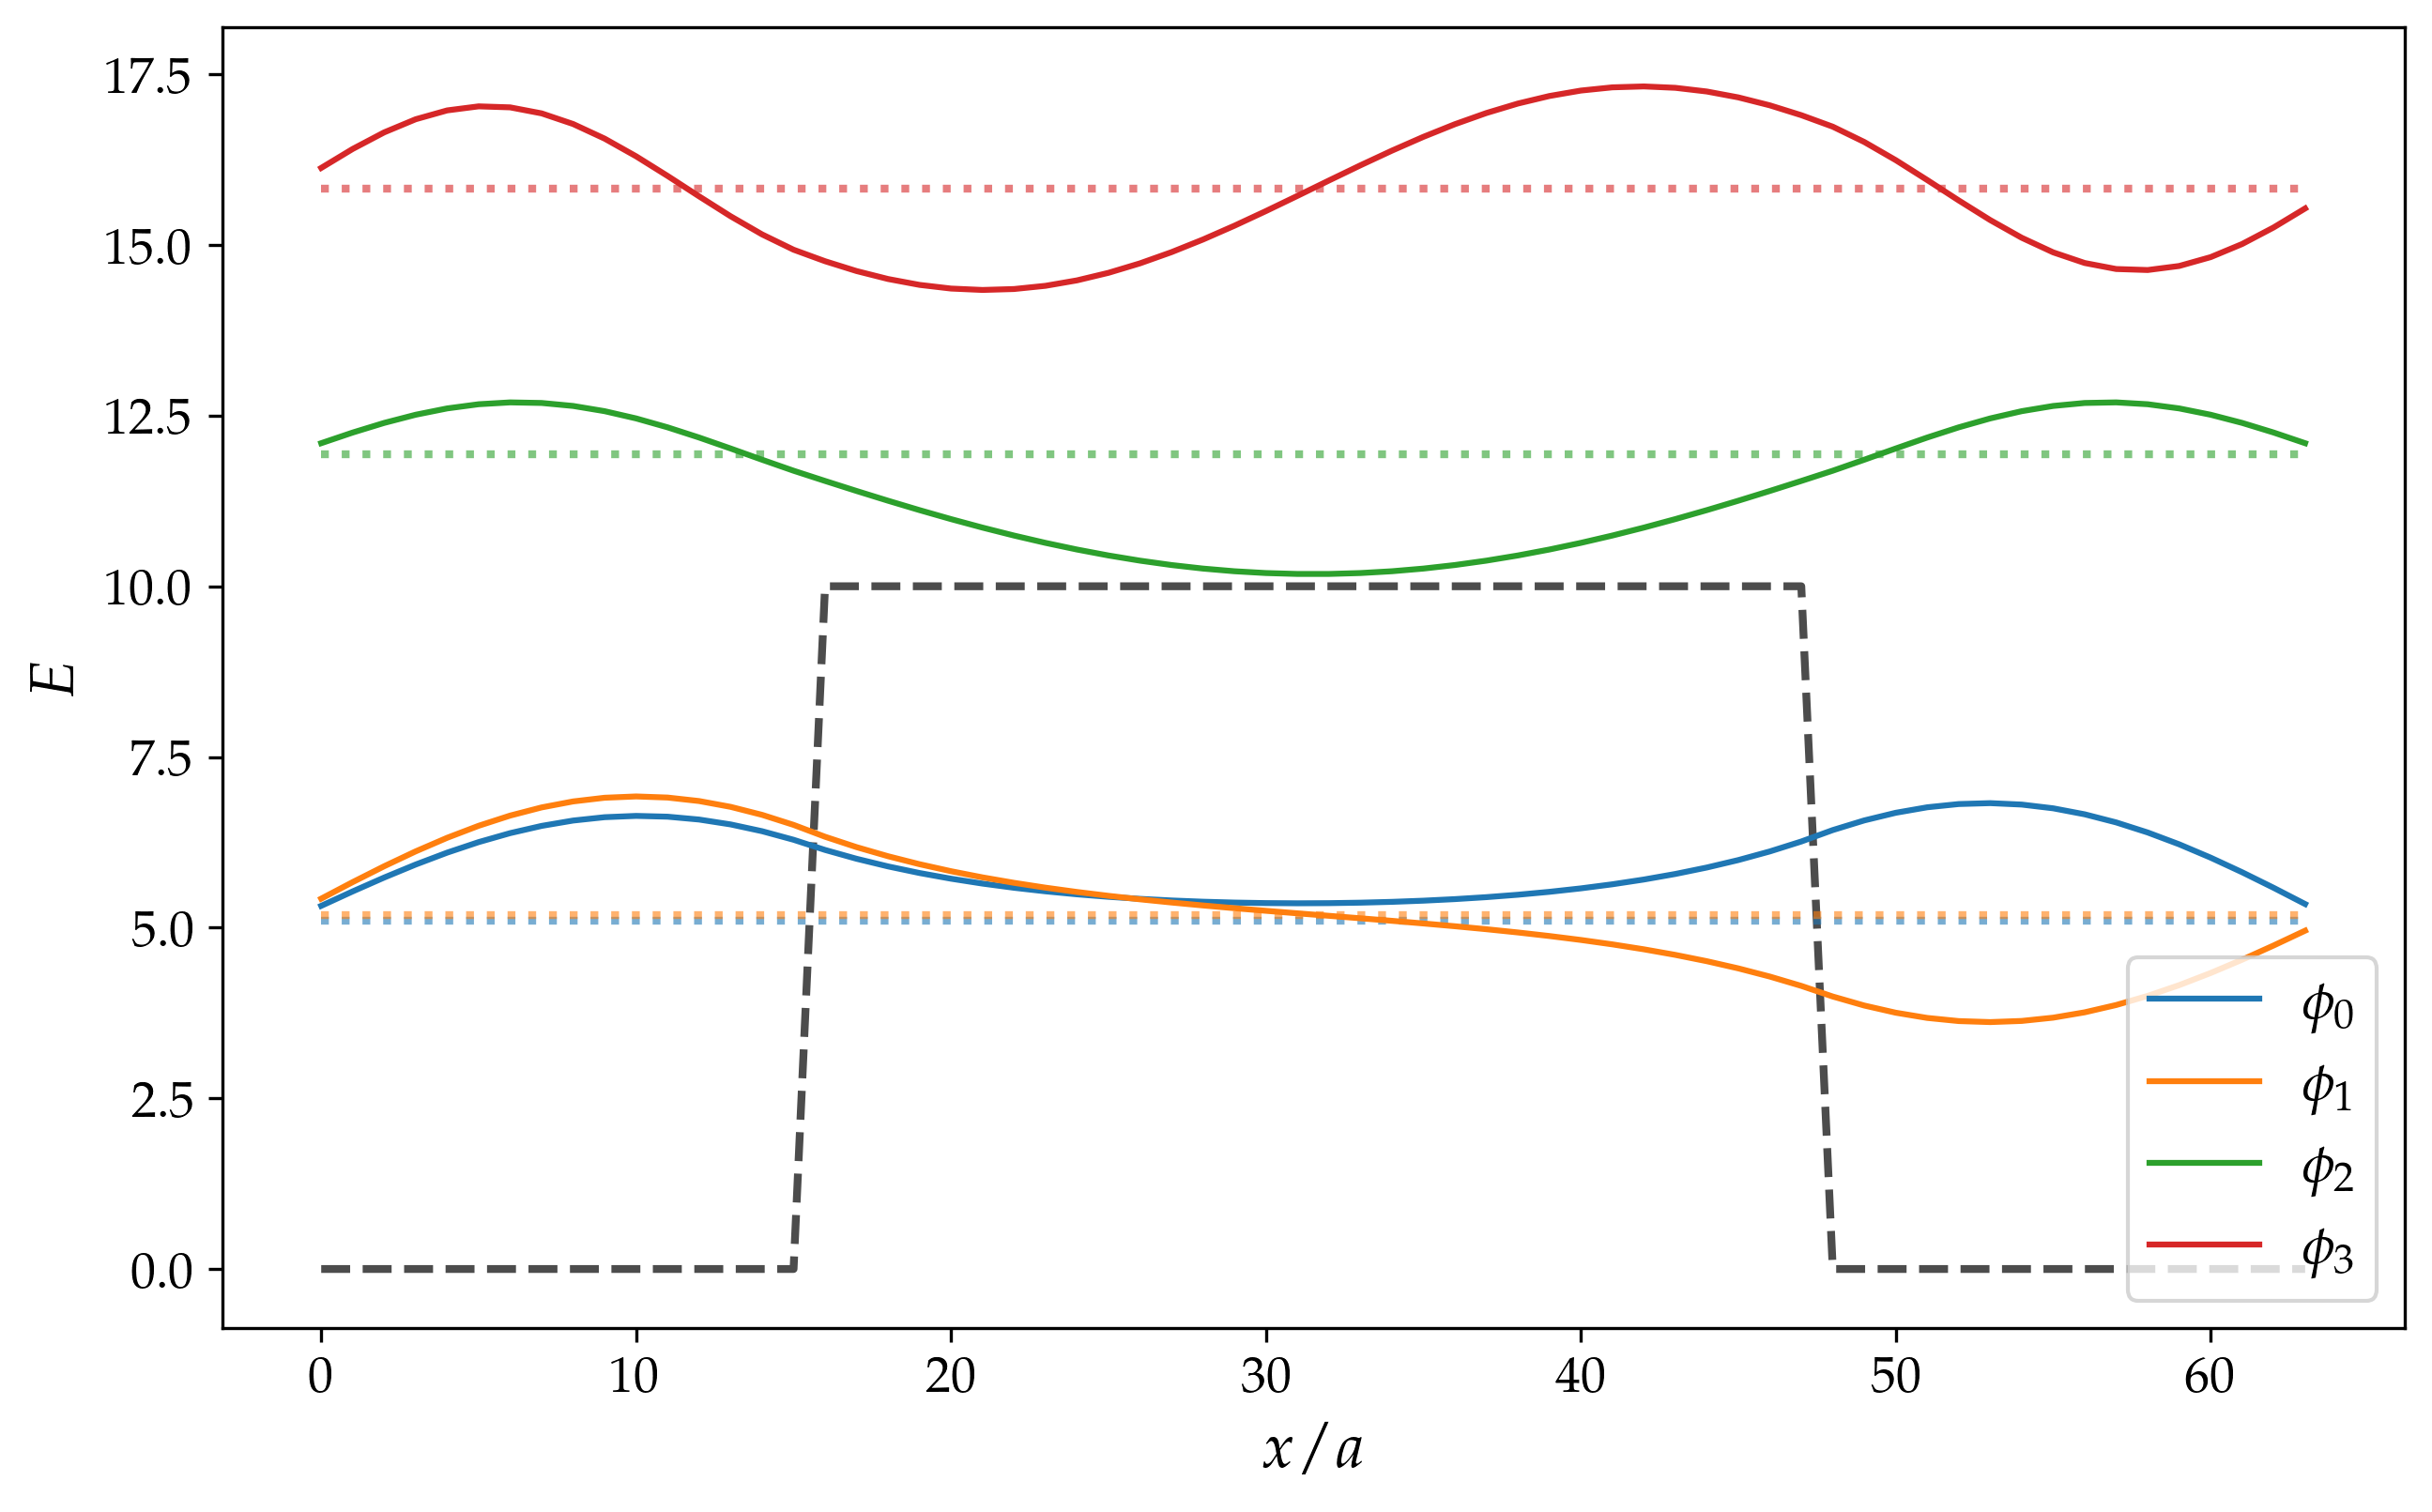

In [4]:
from data_mV import N_points, V0_L, mL, StaticV
tot_eig_val = np.loadtxt('mV_values.txt')
tot_eig_vect = np.loadtxt('mV_vectors.txt')

selec = 4
eig_val = np.copy(tot_eig_val)[:selec]
eig_vect = np.copy(tot_eig_vect)[:, :selec].T

print('Eigenvalues =', eig_val)



xcoo = np.arange(0, N_points)

plt.figure(figsize=(10, 6))
plt.plot(xcoo, StaticV(xcoo), color='black', ls='--', alpha=0.7, 
         lw=2)
for i, eig in enumerate(eig_val):
    plt.hlines(eig, min(xcoo), max(xcoo), color=cols[i], ls=':', alpha=0.6, lw=2)
    plt.plot(xcoo, mL*eig_vect[i] + eig, color=cols[i], zorder=2,
             label=rf'$\phi_{i}$')
    # symmetry
    # plt.plot(np.flip(xcoo), mL*eig_vect[i] + eig, color=cols[i], ls='--', zorder=2)

# plt.vlines(xcoo[-1]/2, 0, np.max(eig_vect)*mL+eig_val[-1],
#            color='black', ls=':', zorder=0, alpha=0.8)

plt.xlabel(r'$x/a$')
plt.ylabel(r'$E$')
plt.legend(loc='lower right')

plt.savefig('plots/finite_wall.png')
plt.show()

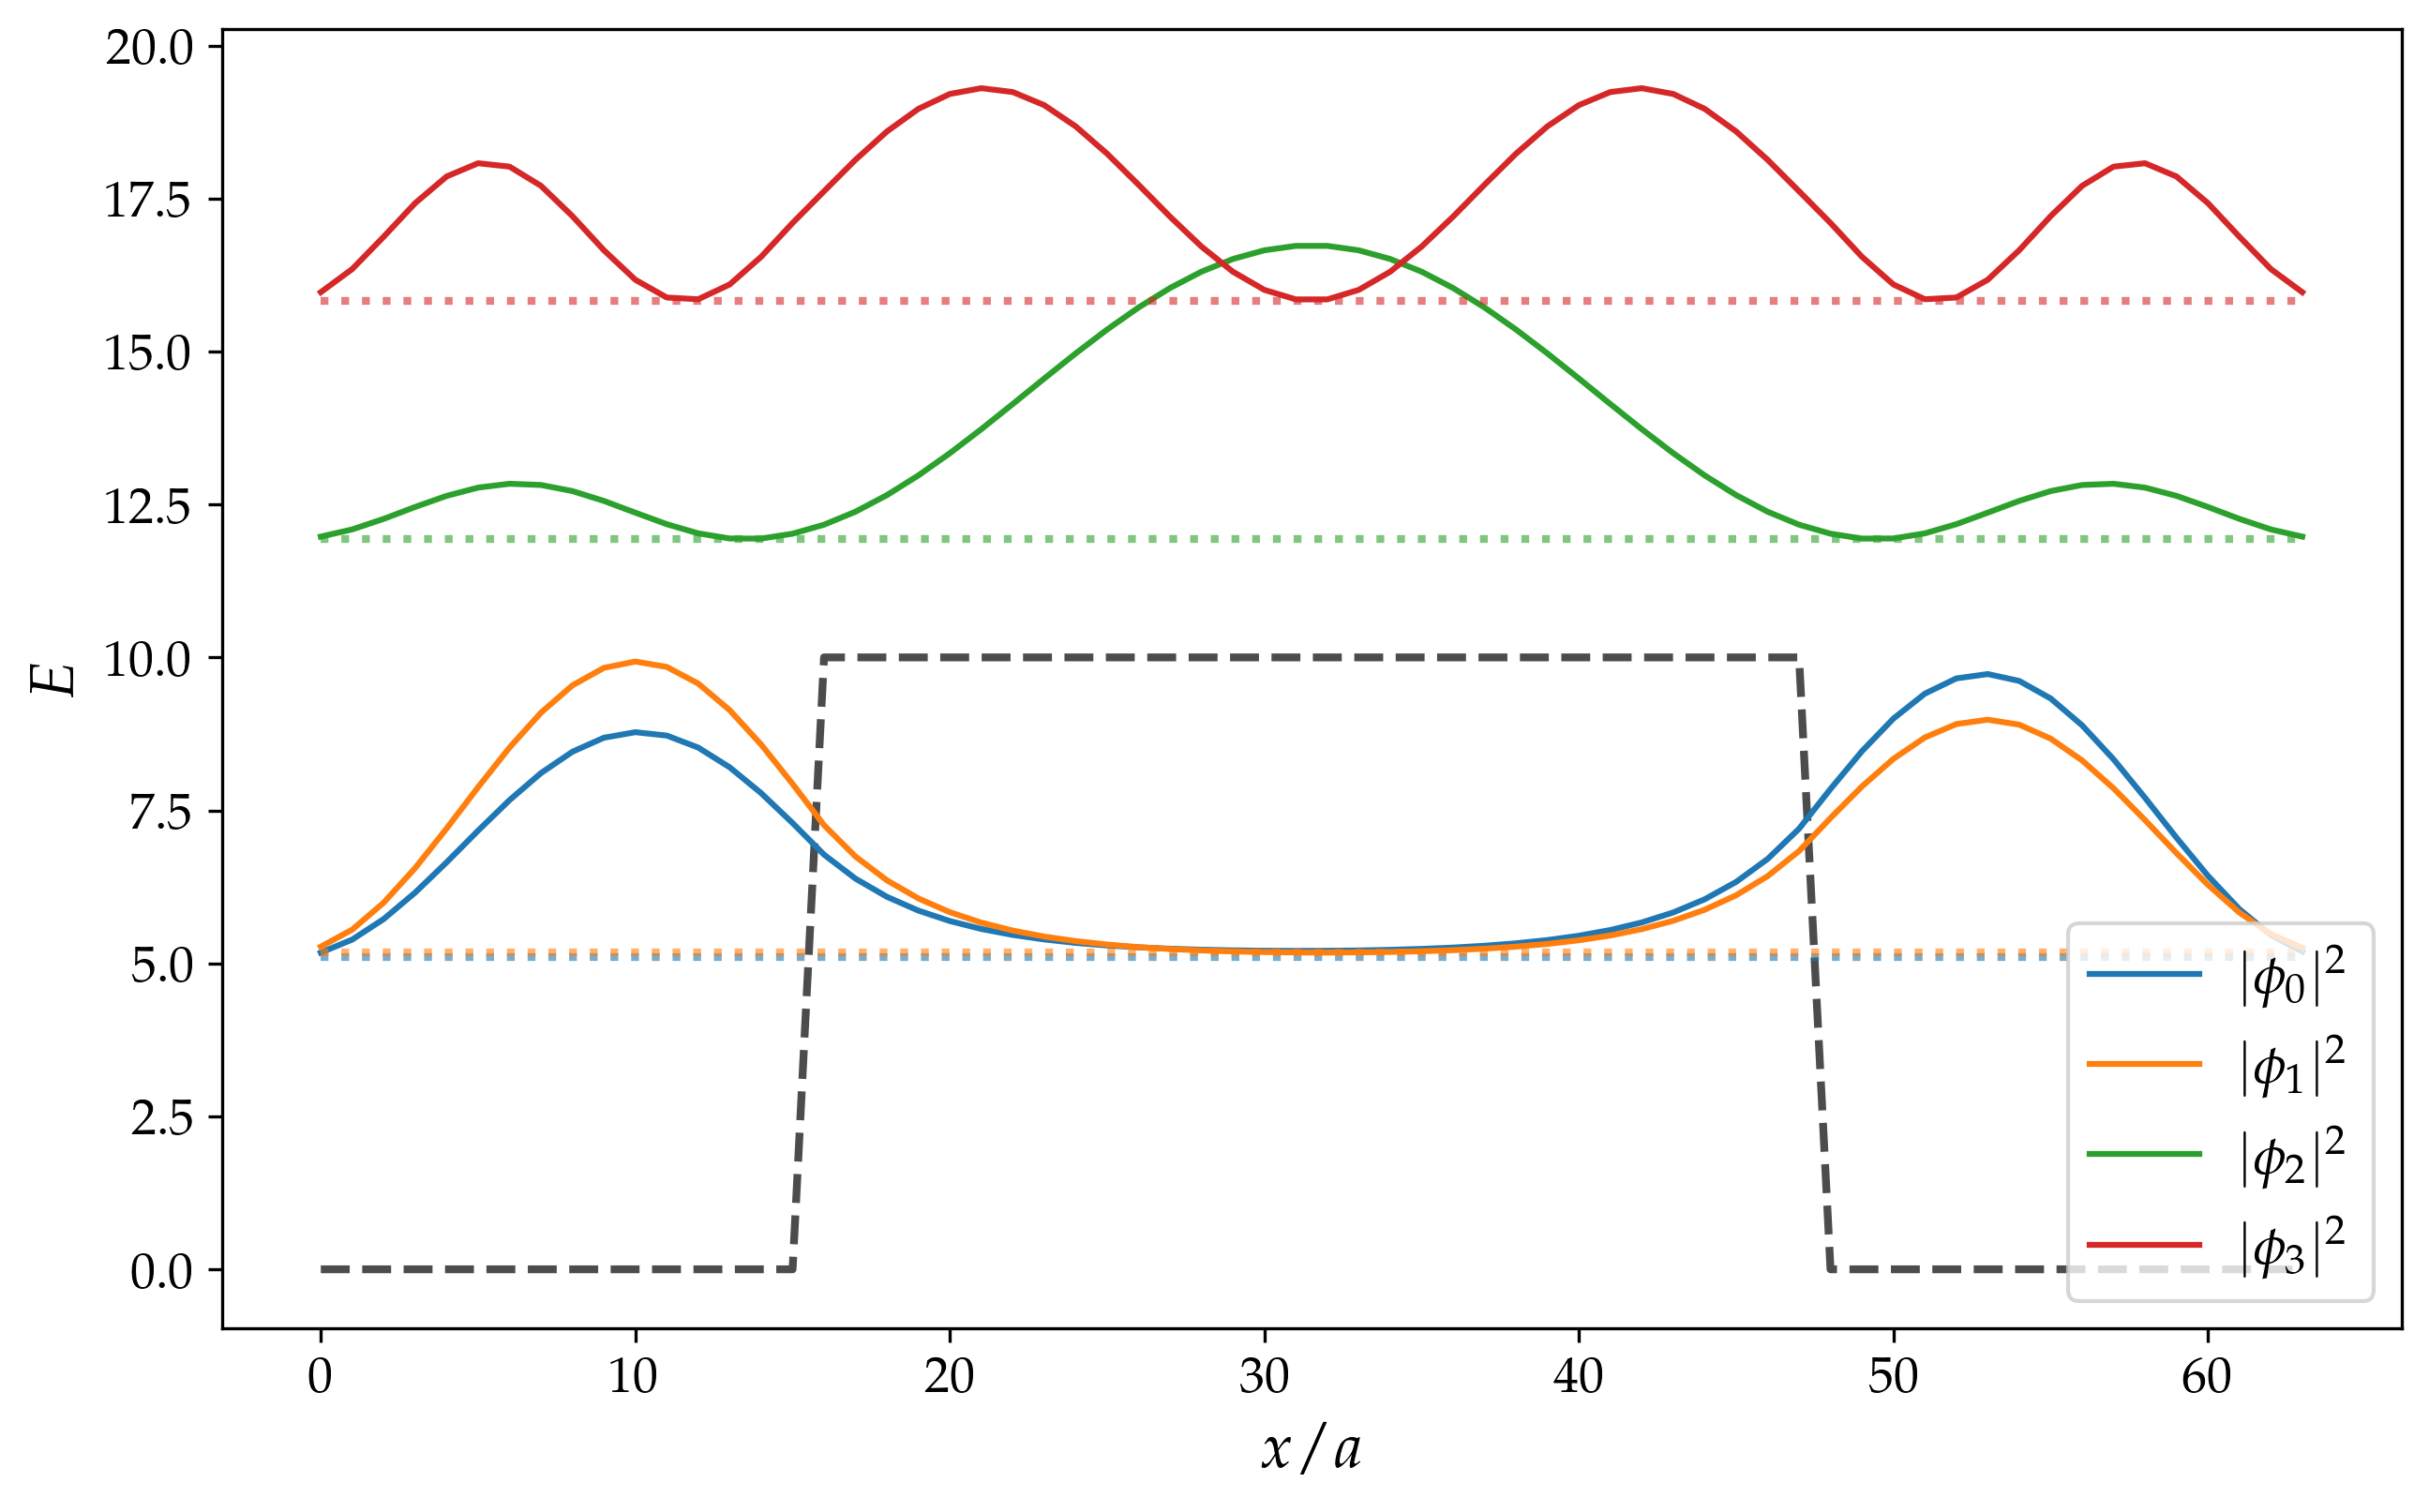

In [5]:

xcoo = np.arange(0, N_points)
eig_vect = eig_vect**2

plt.figure(figsize=(10, 6))
plt.plot(xcoo, StaticV(xcoo), color='black', ls='--', alpha=0.7, 
         lw=2)
for i, eig in enumerate(eig_val):
    plt.hlines(eig, min(xcoo), max(xcoo), color=cols[i], ls=':', alpha=0.6, lw=2)
    plt.plot(xcoo, 100*eig_vect[i] + eig, color=cols[i], zorder=2,
             label=rf'$|\phi_{i}|^2$')
    # symmetry
    # plt.plot(np.flip(xcoo), mL*eig_vect[i] + eig, color=cols[i], ls='--', zorder=2)

# plt.vlines(xcoo[-1]/2, 0, np.max(eig_vect)*mL+eig_val[-1],
#            color='black', ls=':', zorder=0, alpha=0.8)

plt.xlabel(r'$x/a$')
plt.ylabel(r'$E$')
plt.legend(loc='lower right')

plt.savefig('plots/finite_wall_mod2.png')
plt.show()

## **Ground states**

Eigenvalues = [ -8.59332218 -38.1746     -78.02181193]


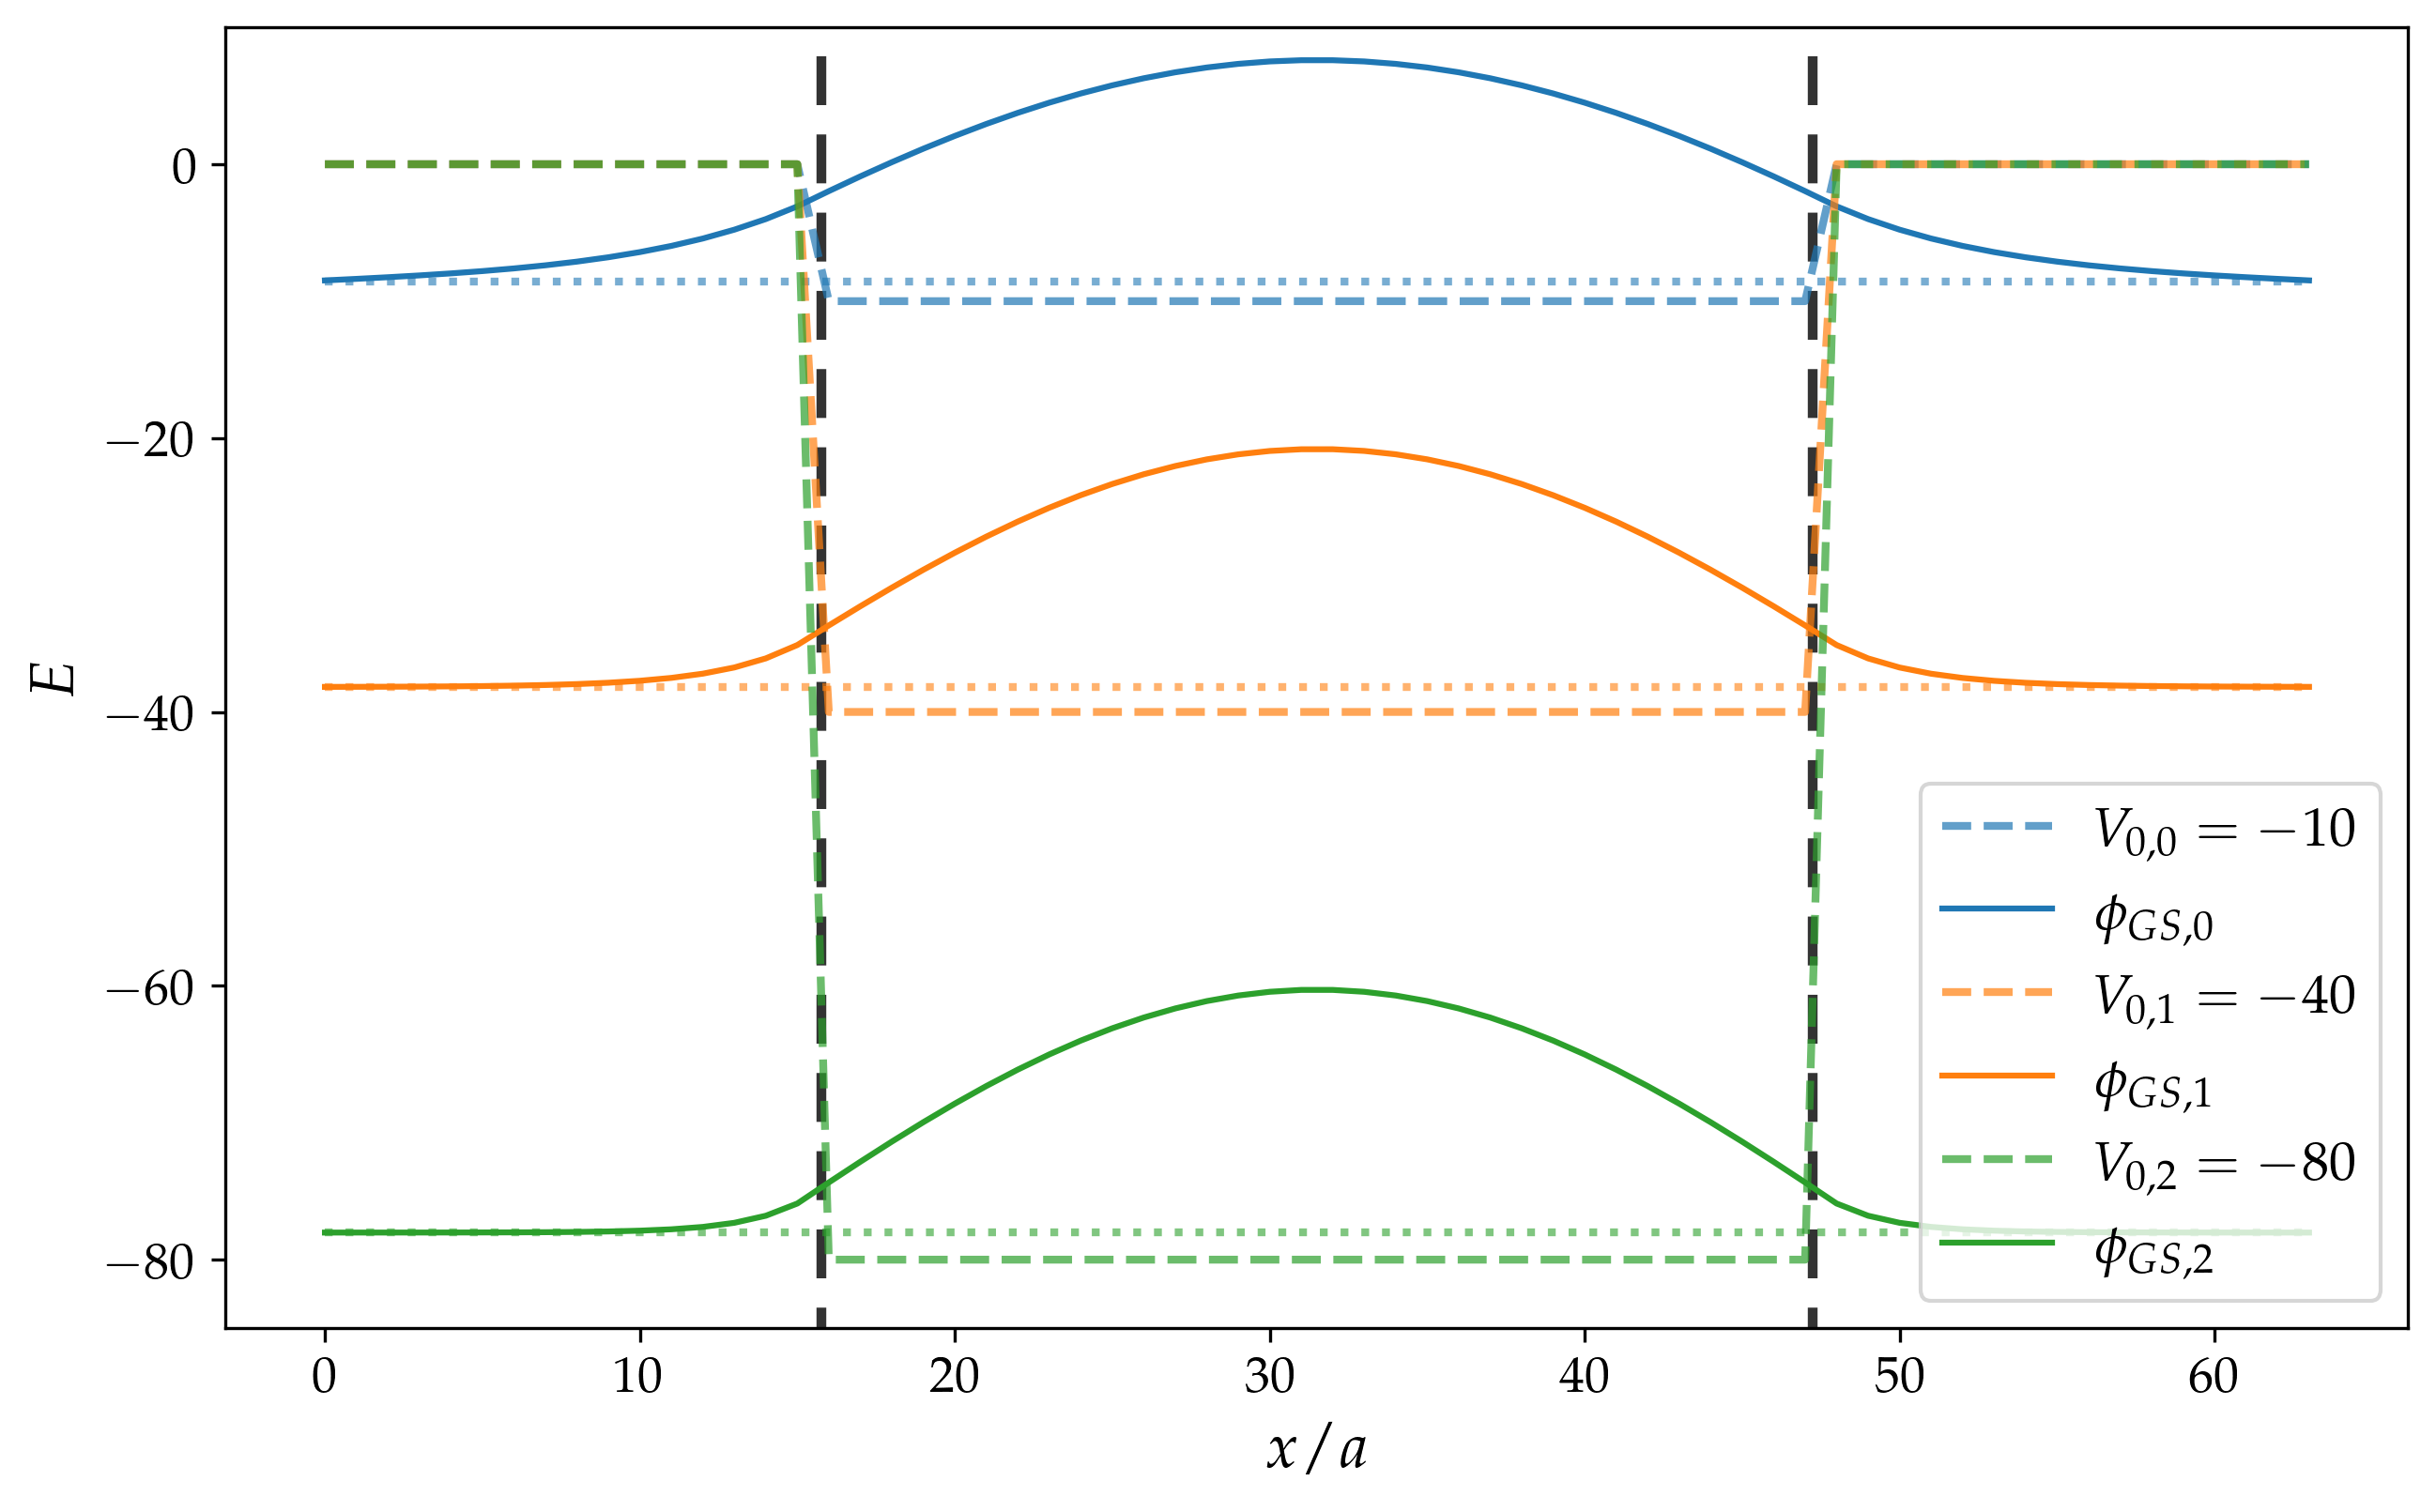

In [6]:

from data_comp import N_points, v_ls, mL
eig_val = np.loadtxt('ground_val.txt')
eig_vect = abs(np.loadtxt('ground_vect.txt'))

print('Eigenvalues =', eig_val)

mL = 75

xcoo = np.arange(0, N_points)

plt.figure(figsize=(10, 6))
for i, eig in enumerate(eig_val):
    def StaticV(x):
        x = np.asarray(x)
        return np.where((x < N_points/4) | (x >= 3/4 * N_points), 0, -v_ls[i])

    plt.plot(xcoo, StaticV(xcoo), color=cols[i], ls='--', alpha=0.7, lw=2,
             label=rf'$V_{{0,{i}}} = -{v_ls[i]}$')
    plt.hlines(eig, min(xcoo), max(xcoo), color=cols[i], ls=':', alpha=0.6, lw=2)
    plt.plot(xcoo, mL*eig_vect[i] + eig, color=cols[i], zorder=2,
             label=rf'$\phi_{{GS,{i}}}$')

bordo = 20
for mul in [1/4, 3/4]:
    plt.vlines(xcoo[-1]*mul, -v_ls[-1]-bordo, bordo,
            color='black', ls=(0, (5, 3)), zorder=0, alpha=0.8, lw=2.5)
plt.ylim(-np.max(v_ls)-5, 10)
plt.xlabel(r'$x/a$')
plt.ylabel(r'$E$')
plt.legend(loc='lower right')

plt.savefig('plots/diff_well.png')
plt.show()

## **Scaling of the eigenvalues**

Eigenvalues =
 [[ -8.64377795  -8.43199722  -8.61471514  -8.60827871  -8.6040371
   -8.6010942   -8.59896816  -8.59738144  -8.59616515  -8.59521171
   -8.59445003  -8.59383154  -8.59332218]
 [  5.0123843    5.29081474   5.4679779    5.58996318   5.67872236
    5.74601658   5.79868916   5.84097886   5.8756442    5.90455392
    5.9290169    5.94997603   5.96812708]
 [ 19.09913866  20.82263004  21.88712963  22.5995037   23.10415788
   23.47745288  23.76313247  23.98784105  24.16862556  24.31684246
   24.44031782  24.54460233  24.63373154]
 [ 35.66255698  41.37665504  44.89214743  47.23129345  48.8743228
   50.07758196  50.98870707  51.69773674  52.26218677  52.72024304
   53.09810023  53.41423832  53.68201548]
 [ 49.70546552  62.8970568   71.31018557  76.98997206  81.00252132
   83.94409721  86.1678169   87.89273527  89.26024979  90.3648251
   91.27148834  92.02618943  92.66215334]
 [ 59.63528011  81.73656909  97.74526218 108.96489868 117.03032765
  122.99570495 127.52458615 131.04300919 

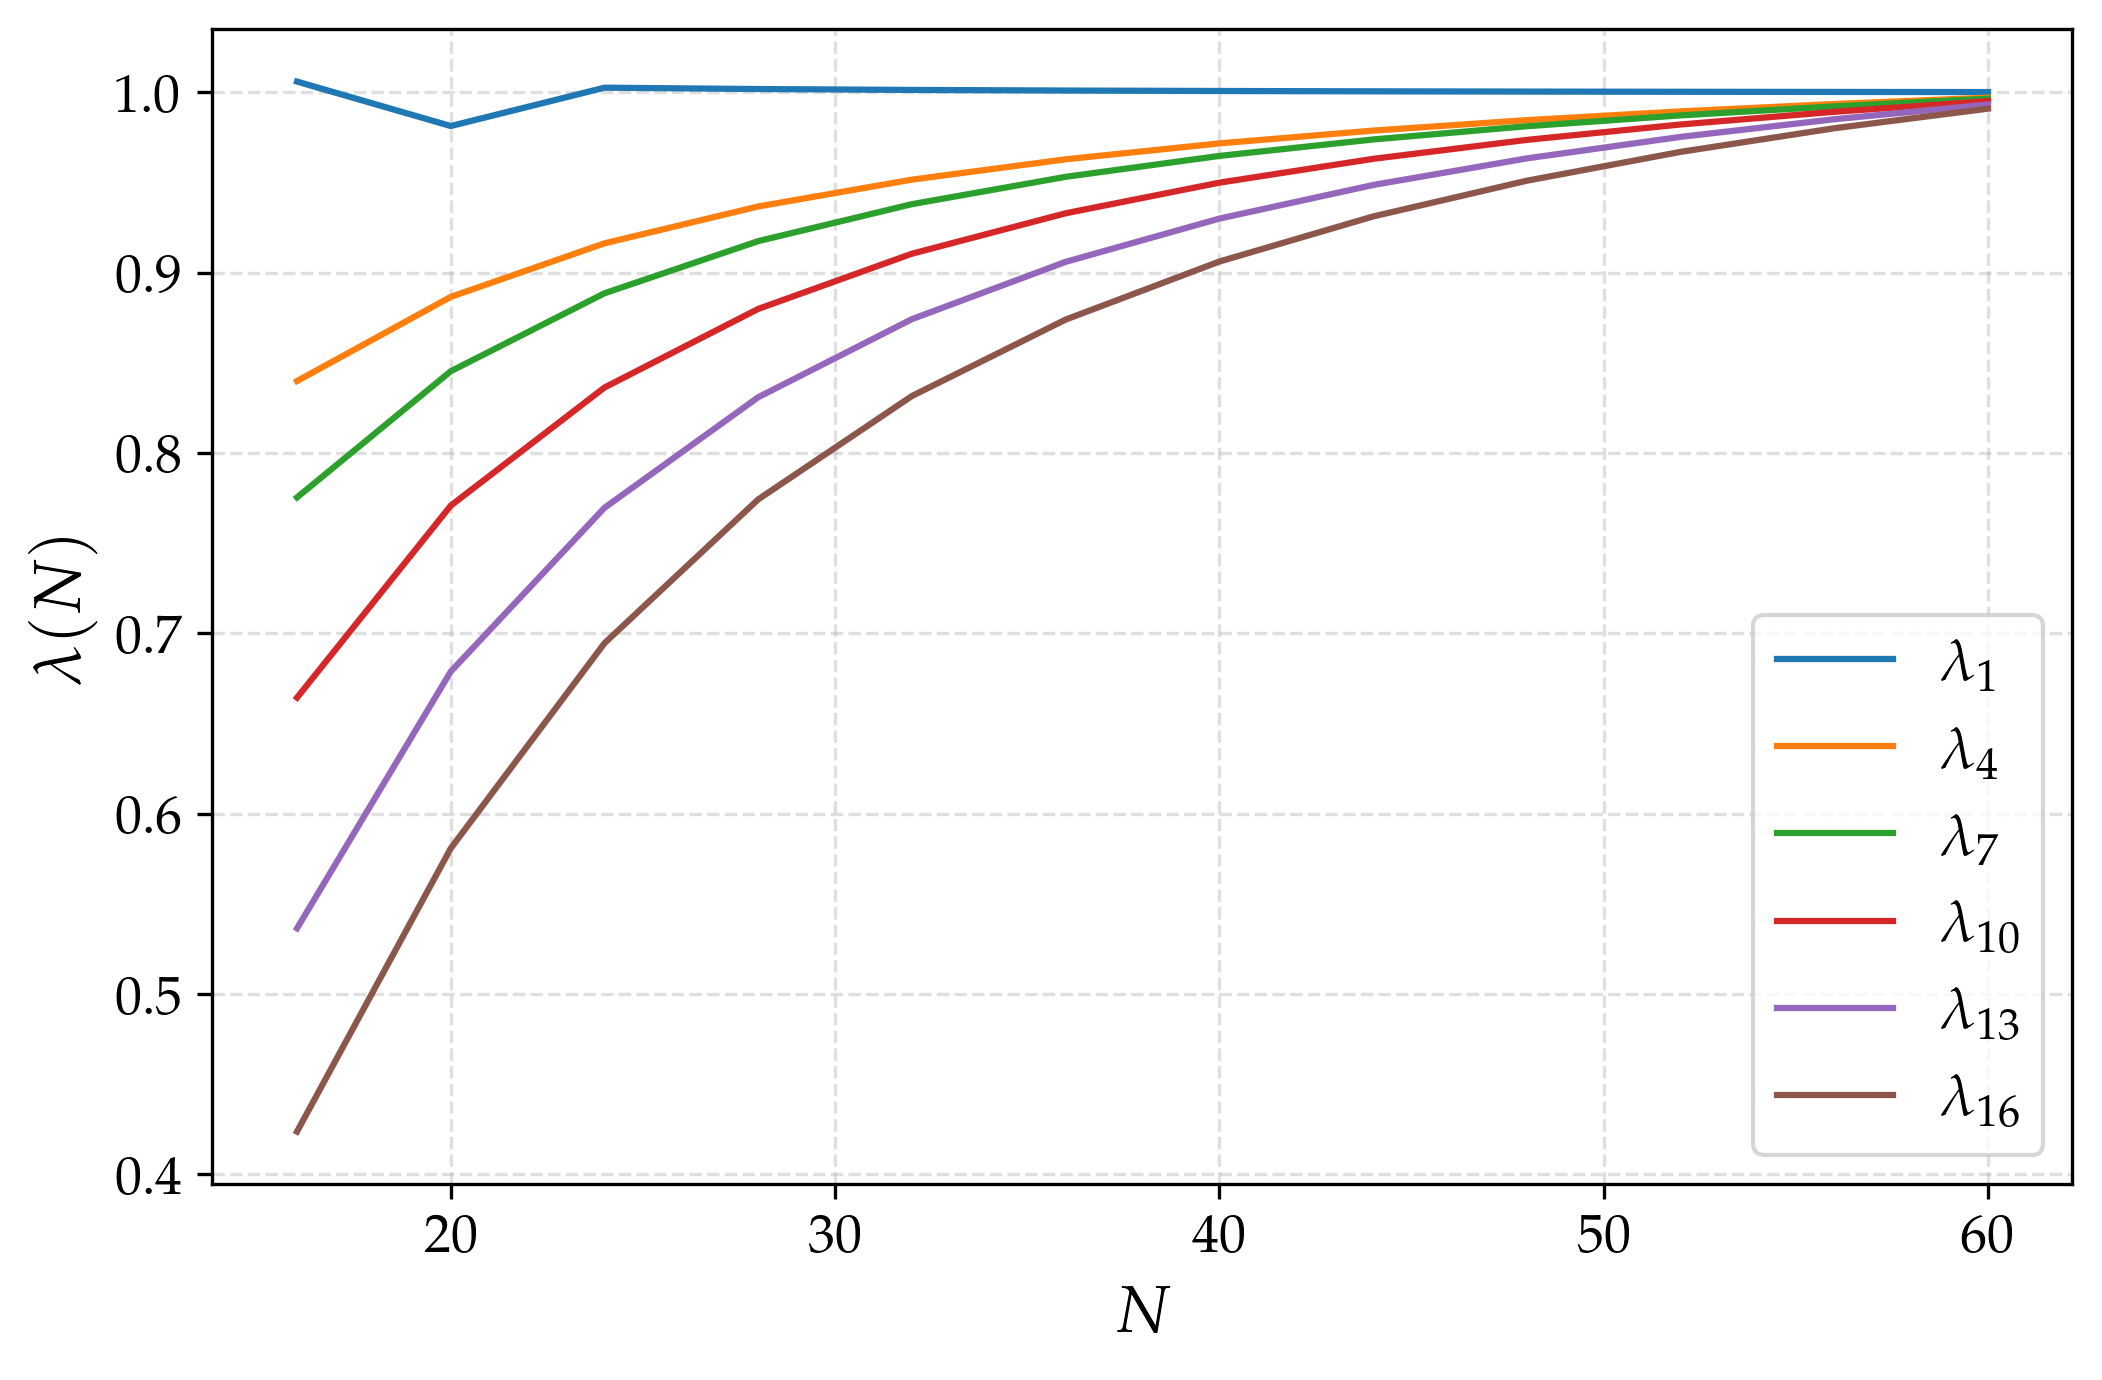

In [7]:

from func_N import N_ls, orders
eig_val = np.loadtxt('scal_N_val.txt')
print('Eigenvalues =\n', eig_val.T)

eig_i = eig_val[:-1, 0] / eig_val[-1, 0]

plt.figure(figsize=(8,5))
for i in range(len(orders)):
    eig_i = eig_val[:-1, i] / eig_val[-1, i]
    plt.plot(N_ls[:-1], eig_i, label=rf'$\lambda_{{{orders[i]+1}}}$')


plt.xlabel(r'$N$')
plt.ylabel(r'$\lambda (N)$')
plt.legend(loc='lower right')
plt.grid(alpha=0.4, ls='--')

plt.savefig('plots/rate_N.png')
plt.show()


## **Different $V_0$ models**


-----------------------------------
	Finite well
-----------------------------------
Eigenvalues = [-8.65612785 -4.82240447  0.65761988  5.82313703]

-----------------------------------
	Double well
-----------------------------------
Eigenvalues = [-9.36008308 -7.88497084  6.50988642 16.99803965]

-----------------------------------
	Triangular well
-----------------------------------
Eigenvalues = [ 7.19381956 14.00823571 19.576881   24.77510148]

-----------------------------------
	Alpha well
-----------------------------------
Eigenvalues = [-3.82560631  1.95880909  5.19409947  9.5888013 ]


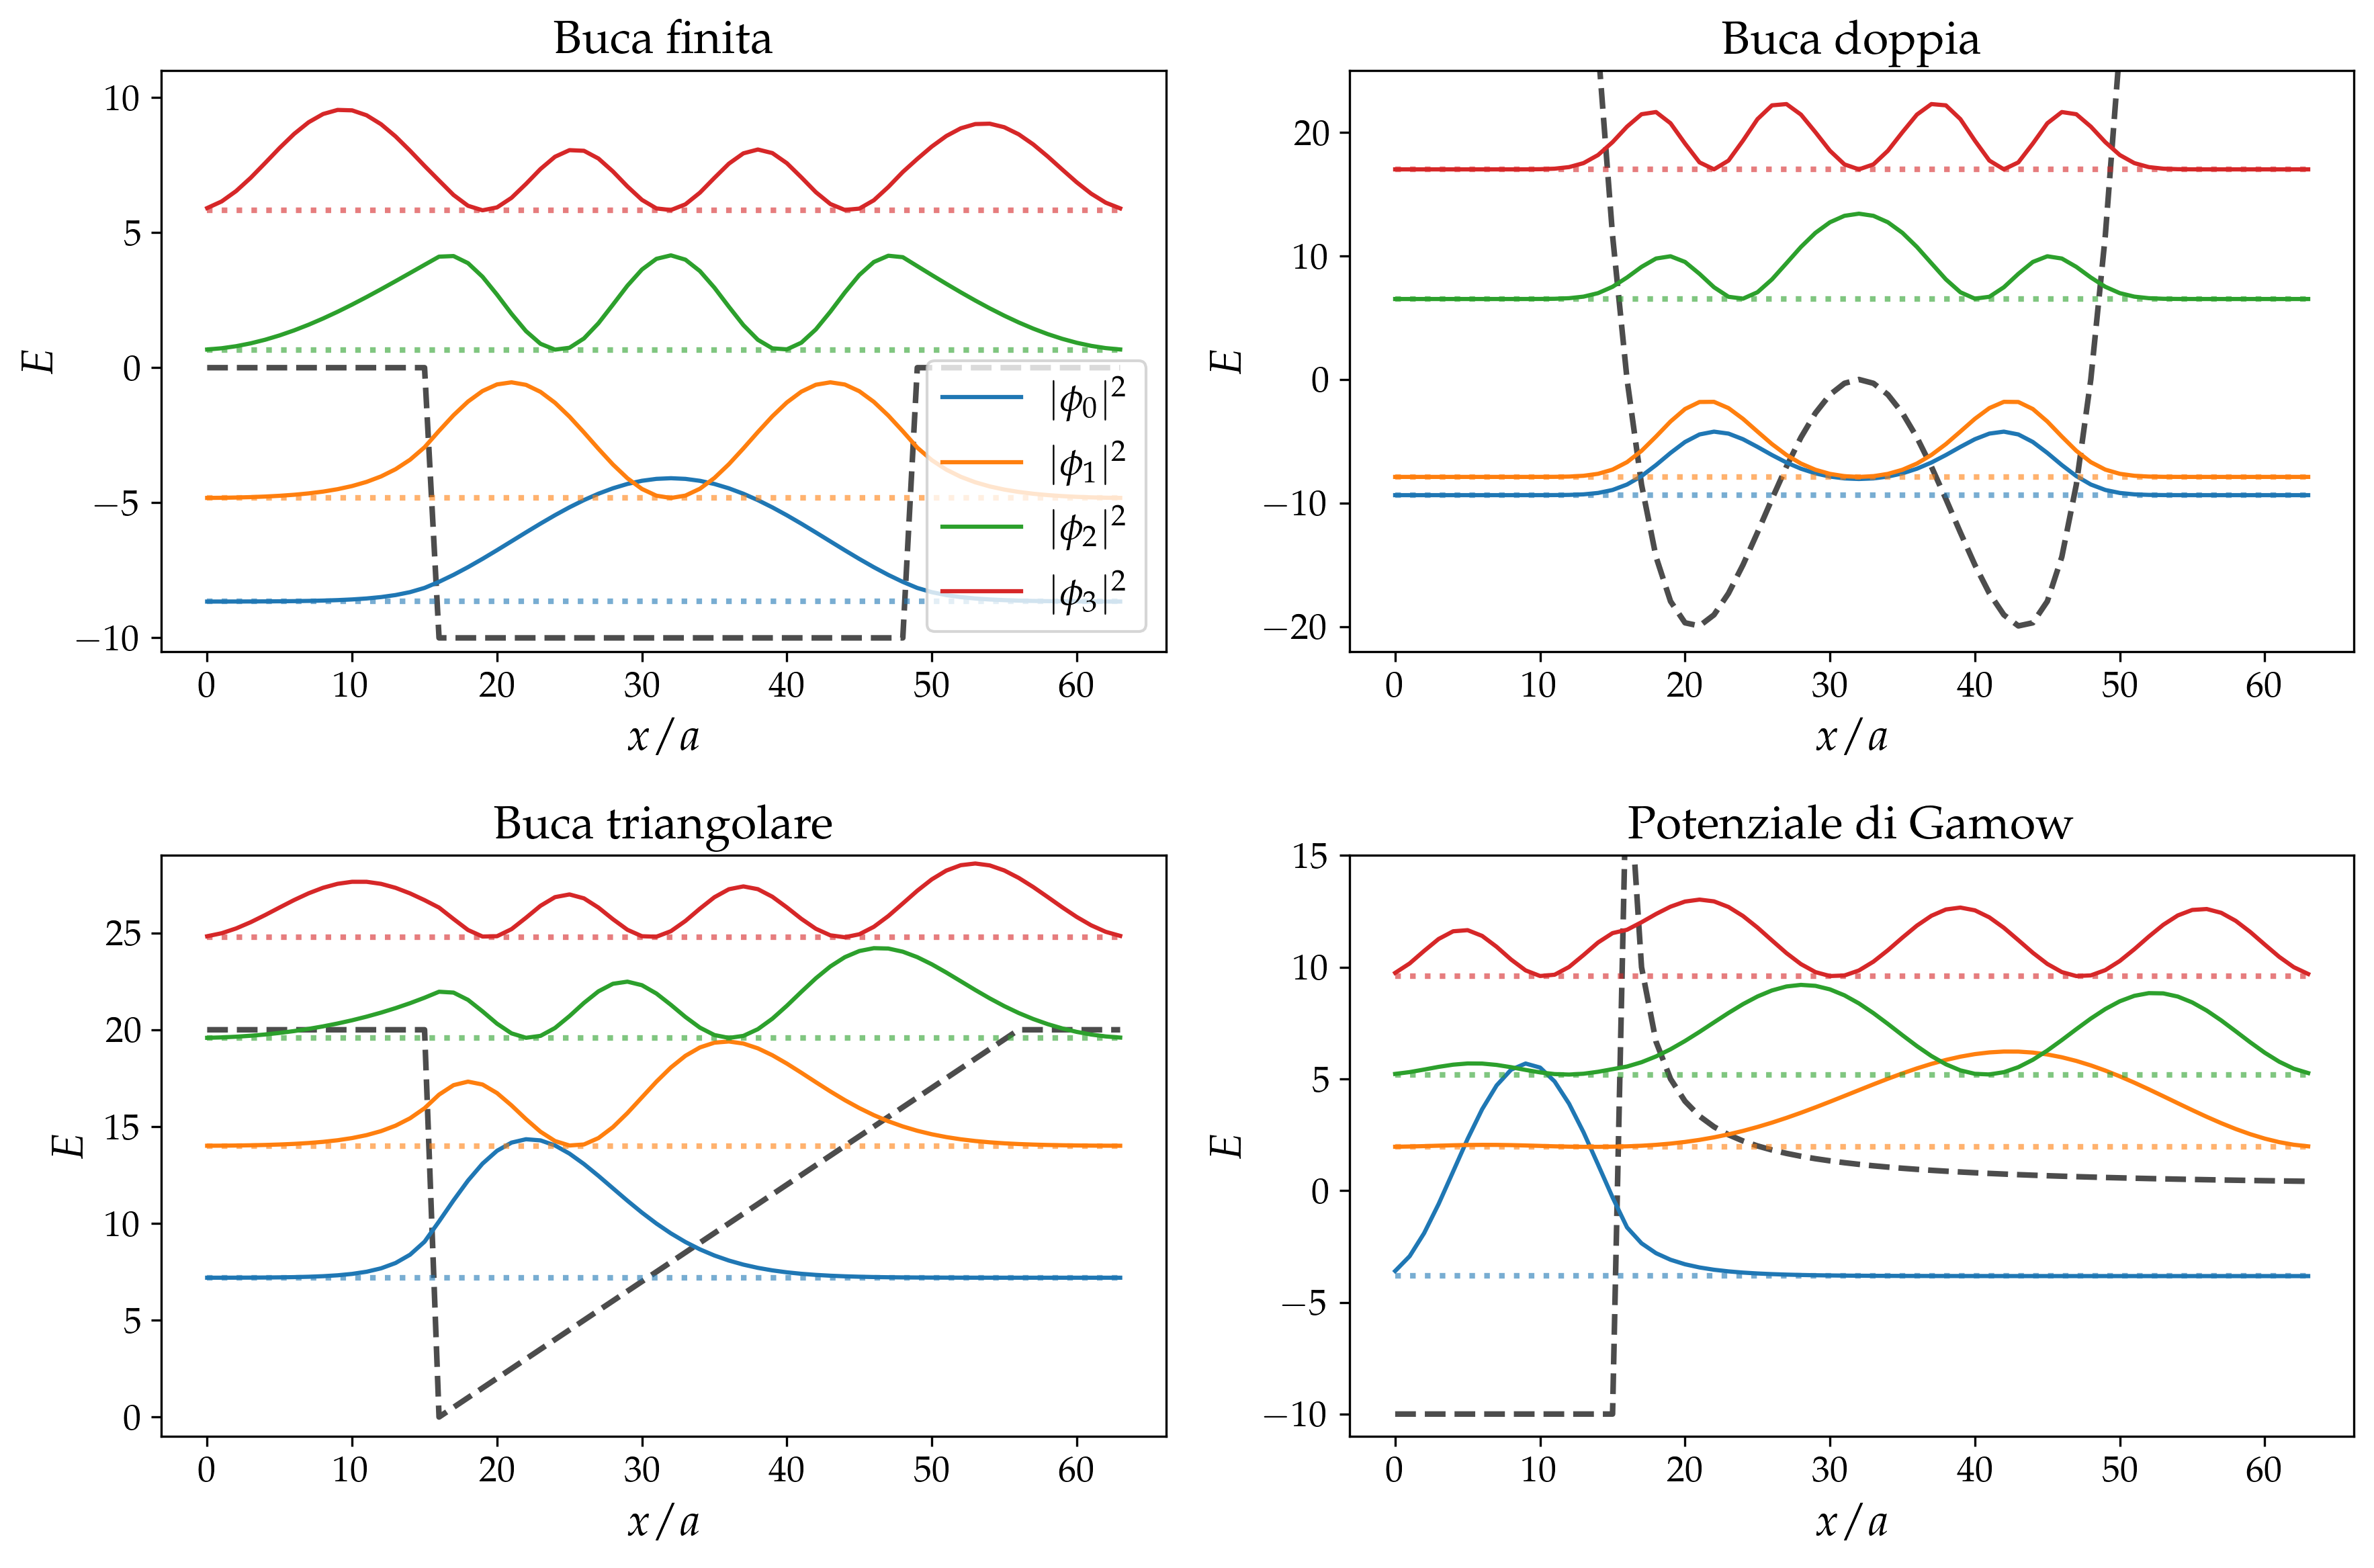

In [ ]:
from data_diffV import N_points, mL, static_V_ls , names

mL = 100

tot_eig_val = np.load('diff_val.npy')
tot_eig_vect = np.load('diff_vect.npy')

selec = 4
eig_val = np.copy(tot_eig_val)[:, :selec]
eig_vect = np.copy(tot_eig_vect)[:, :, :selec]

xcoo = np.arange(0, N_points)
cols = [f'C{i}' for i in range(10)]


names_ita = [
    'Buca finita',
	'Buca doppia',
	'Buca triangolare',
	'Potenziale di Gamow'
]

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

lims = [[-10.5, 11],
        [-22, 25],
        [-1, 29],
        [-11, 15]]

for k, StaticV in enumerate(static_V_ls):
	plt.sca(ax[k])
	eig_val_k = eig_val[k]
	eig_vect_k = eig_vect[k,:, :]
	eig_vect_k = eig_vect_k**2

	print(f'''\n-----------------------------------
	{names[k]}
-----------------------------------''')


	print('Eigenvalues =', eig_val_k)
	plt.plot(xcoo, StaticV(xcoo), color='black', ls='--', alpha=0.7, lw=2)
	for i, eig in enumerate(eig_val_k):
		vect = mL*eig_vect_k[:, i] + eig
		plt.hlines(eig, min(xcoo), max(xcoo), color=cols[i], ls=':', alpha=0.6, lw=2)
		plt.plot(xcoo, vect, color=cols[i], zorder=2,
				 label=rf'$|\phi_{i}|^2$')
		plt.title(names_ita[k])

	plt.ylim(*lims[k])
	plt.xlabel(r'$x/a$')
	plt.ylabel(r'$E$')
	
	if k==0:
		plt.legend(loc='lower right')
	else:
		pass

plt.tight_layout()
plt.savefig('plots/comp_Vs.png')
plt.show()
